# 02b — Feature Engineering V2

Builds an improved model-ready dataset. Assumes the raw `.7z` files have already
been extracted by `02_feature_engineering.ipynb` (processed CSVs must exist).

**Changes vs V1 (`02_feature_engineering.ipynb`):**

| What | V1 | V2 |
|---|---|---|
| Short lags | — | `lag_1h`, `lag_2h`, `lag_3h` |
| Medium lag | `lag_48h` missing | `lag_48h` added |
| Rolling windows | 3h only | 3h + 6h + 24h |
| Neighbor context | — | `neighbor_mean_occ` (5 nearest stations) |
| Tomorrow holiday | — | `is_holiday_tomorrow` |
| Redundant features | `is_weekend`, `month_sin/cos` | removed |

**Output:** `data/processed/bicing_model_dataset_v2.parquet`

In [14]:
import sys
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()
sys.path.append(str(PROJECT_ROOT))

import gc
import pandas as pd
import numpy as np

from src.data.loader import load_station_info, load_station_status, fetch_weather
from src.data.features import add_occupancy, add_temporal_features
from src.data.features_v2 import (
    add_distance_features,
    add_cyclic_features,
    add_day_type,           # V2 version: adds is_holiday_tomorrow, drops is_weekend
    build_model_dataset_v2,
)
from src.utils.config import PATHS, SPLIT_DATE, HORIZONS, DATASET_FILE_V2, FEATURES_V2

OUTPUT_PATH = DATASET_FILE_V2
print(f'Output: {OUTPUT_PATH}')

Output: C:\Users\user\Downloads\Data Science ML Bicing bcn\Data Science ML Bicing\bicing-occupancy-prediction\data\processed\bicing_model_dataset_v2.parquet


---
## Step 1 — Load station status (hourly)

Assumes processed CSVs already exist. If not, run `02_feature_engineering.ipynb` first.

In [15]:
df_hourly = load_station_status()
print(df_hourly.shape)
df_hourly.head(3)

  Loading 2024_01_Gener_BicingNou_ESTACIONS.csv...


C:\Users\user\Downloads\Data Science ML Bicing bcn\Data Science ML Bicing\bicing-occupancy-prediction\src\data\loader.py:75: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, encoding="utf-8-sig")


  Loading 2024_02_Febrer_BicingNou_ESTACIONS.csv...


C:\Users\user\Downloads\Data Science ML Bicing bcn\Data Science ML Bicing\bicing-occupancy-prediction\src\data\loader.py:75: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, encoding="utf-8-sig")


  Loading 2024_03_Marc_BicingNou_ESTACIONS.csv...


...

C:\Users\user\Downloads\Data Science ML Bicing bcn\Data Science ML Bicing\bicing-occupancy-prediction\src\data\loader.py:75: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, encoding="utf-8-sig")


  Loading 2024_12_Desembre_BicingNou_ESTACIONS.csv...


C:\Users\user\Downloads\Data Science ML Bicing bcn\Data Science ML Bicing\bicing-occupancy-prediction\src\data\loader.py:75: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, encoding="utf-8-sig")



Raw rows (IN_SERVICE): 49,557,604
After hourly aggregation: 4,145,095 rows
(4145095, 6)


,station_id,datetime_hour,bikes_total,bikes_mechanical,bikes_electric,docks_available
0,1.0,2023-12-31 22:00:00,12.000000,2.000000,10.000000,33.000000
1,1.0,2023-12-31 23:00:00,9.583333,2.250000,7.333333,35.333333
2,1.0,2024-01-01 00:00:00,10.500000,3.916667,6.583333,34.416667


---
## Step 2 — Station info and distances

In [17]:
df_stations = load_station_info()
df_stations = add_distance_features(df_stations)
print(df_stations[['name', 'capacity', 'dist_beach', 'dist_center']].head(5))

Station info loaded: 510 stations
                                        name  capacity  dist_beach  \
4363896        GRAN VIA CORTS CATALANES, 760        46       2.311   
4363897                C/ ROGER DE FLOR, 126        29       2.203   
4363898                        C/ NÀPOLS, 82        27       1.890   
4363899                         C/ RIBES, 13        21       1.814   
4363900  PG. LLUIS COMPANYS, 11 (ARC TRIOMF)        39       1.666   

         dist_center  
4363896        1.447  
4363897        1.081  
4363898        1.207  
4363899        1.146  
4363900        0.944  


In [16]:
df_hourly['station_id'] = df_hourly['station_id'].astype(int)
df_full = df_hourly.merge(df_stations, on='station_id', how='left')

unmatched = df_full['lat'].isnull().sum()
print(f'Rows without station info: {unmatched} ({unmatched/len(df_full)*100:.2f}%)')
df_full = df_full.dropna(subset=['lat'])

del df_hourly
gc.collect()

print(f'Shape after merge: {df_full.shape}')

Rows without station info: 29377 (0.71%)
Shape after merge: (4115718, 12)


---
## Step 3 — Occupancy

In [18]:
df_full = add_occupancy(df_full)
print(f'After occupancy: {df_full.shape}')
print(f'Occupancy range: {df_full["occupancy"].min():.3f} — {df_full["occupancy"].max():.3f}')

After occupancy: (4115718, 13)
Occupancy range: 0.000 — 1.000


---
## Step 4 — Weather

In [19]:
start = str(df_full['datetime_hour'].min().date())
end   = str(df_full['datetime_hour'].max().date())
df_weather = fetch_weather(start, end)

df_full = df_full.merge(df_weather, on='datetime_hour', how='left')
del df_weather
gc.collect()

print(f'Weather nulls: {df_full["temperature"].isnull().sum()}')

Weather fetched: 482,136 hourly rows (1970-01-01 → 2024-12-31)
Weather nulls: 0


---
## Step 5 — Temporal features and day type

V2 differences:
- `add_day_type` from `features_v2` adds `is_holiday_tomorrow`, drops `is_weekend`
- `add_cyclic_features` from `features_v2` drops `month_sin/cos`

In [20]:
df_full = add_temporal_features(df_full)
df_full = add_day_type(df_full)
df_full = add_cyclic_features(df_full)

print(df_full[['hour', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
               'is_holiday', 'is_holiday_tomorrow']].head(3))

   hour  hour_sin  hour_cos   dow_sin  dow_cos  is_holiday  \
0    22 -0.500000  0.866025 -0.781831  0.62349           0   
1    23 -0.258819  0.965926 -0.781831  0.62349           0   
2     0  0.000000  1.000000  0.000000  1.00000           1   

   is_holiday_tomorrow  
0                    1  
1                    1  
2                    0  


---
## Step 6 — Temporal split

In [21]:
train_mask = df_full['datetime_hour'] < SPLIT_DATE
print(f'Train rows: {train_mask.sum():,}  ({train_mask.mean()*100:.1f}%)')
print(f'Test rows:  {(~train_mask).sum():,}')

Train rows: 3,378,026  (82.1%)
Test rows:  737,692


---
## Step 7 — Full V2 feature pipeline

Runs in one call:
- Lag features: `lag_1h`, `lag_2h`, `lag_3h`, `lag_24h`, `lag_48h`, `lag_168h`
- Rolling means: 3h, 6h, 24h
- `hist_mean_occ` computed on train rows only (no leakage)
- `neighbor_mean_occ` — mean occupancy of the 5 nearest stations at T
- Horizon expansion to all horizons in `HORIZONS`

In [22]:
import gc

print(f'Before pipeline: {len(df_full):,} rows')

df_model = build_model_dataset_v2(
    df_full,
    df_stations=df_stations,
    train_mask=train_mask,
    horizons=HORIZONS,
    n_neighbors=5,
)

del df_full
gc.collect()

print(f'After pipeline:  {len(df_model):,} rows  ({len(HORIZONS)} horizons)')
print(f'Horizons present: {sorted(df_model["horizon_hours"].unique())}')

Before pipeline: 4,115,718 rows
After pipeline:  20,142,030 rows  (5 horizons)
Horizons present: [np.int8(1), np.int8(3), np.int8(6), np.int8(12), np.int8(24)]


---
## Step 8 — Validation checks

In [23]:
TARGET = 'target_occ'

missing = [f for f in FEATURES_V2 if f not in df_model.columns]
if missing:
    print(f'WARNING — missing features: {missing}')
else:
    print('All V2 features present.')

nulls = df_model[FEATURES_V2 + [TARGET]].isnull().sum()
nulls = nulls[nulls > 0]
if len(nulls):
    print(f'Nulls remaining:\n{nulls}')
else:
    print('No nulls in model features or target.')

All V2 features present.
Nulls remaining:
neighbor_mean_occ    5
dtype: int64


In [24]:
print(f'Final shape:  {df_model.shape}')
print(f'Stations:     {df_model["station_id"].nunique()}')
print(f'Date range:   {df_model["datetime_hour"].min()} -> {df_model["datetime_hour"].max()}')
print()
print(df_model[FEATURES_V2 + [TARGET]].describe().round(3))

Final shape:  (20142030, 32)
Stations:     510
Date range:   2024-01-07 18:00:00 -> 2024-12-31 22:00:00

           hour_sin      hour_cos       dow_sin       dow_cos  \
count  2.014203e+07  2.014203e+07  2.014203e+07  2.014203e+07   
mean   1.000000e-03 -0.000000e+00  9.000000e-03 -2.000000e-03   
std    7.070000e-01  7.070000e-01  7.070000e-01  7.070000e-01   
min   -1.000000e+00 -1.000000e+00 -9.750000e-01 -9.010000e-01   
25%   -7.070000e-01 -7.070000e-01 -7.820000e-01 -9.010000e-01   
50%    0.000000e+00  0.000000e+00  0.000000e+00 -2.230000e-01   
75%    7.070000e-01  7.070000e-01  7.820000e-01  6.230000e-01   
max    1.000000e+00  1.000000e+00  9.750000e-01  1.000000e+00   

       target_hour_sin  target_hour_cos    is_holiday  is_holiday_tomorrow  \
count     2.014203e+07     2.014203e+07  2.014203e+07         2.014203e+07   
mean     -0.000000e+00    -0.000000e+00  3.300000e-02         3.500000e-02   
std       7.070000e-01     7.070000e-01  1.790000e-01         1.840000e-01 

---
## Step 9 — Feature comparison: V1 vs V2

In [26]:
from src.utils.config import FEATURES

v1_set = set(FEATURES)
v2_set = set(FEATURES_V2)

print('Features added in V2:')
for f in sorted(v2_set - v1_set):
    print(f'  + {f}')

print('\nFeatures removed in V2:')
for f in sorted(v1_set - v2_set):
    print(f'  - {f}')

print(f'\nTotal: {len(FEATURES)} -> {len(FEATURES_V2)} features')

Features added in V2:
  + is_holiday_tomorrow
  + lag_1h
  + lag_2h
  + lag_3h
  + lag_48h
  + neighbor_mean_occ
  + rolling_mean_24h
  + rolling_mean_6h

Features removed in V2:
  - is_weekend
  - month_cos
  - month_sin

Total: 22 -> 27 features


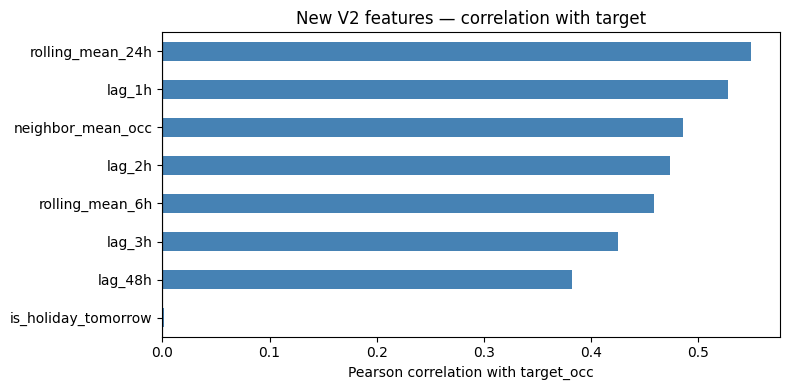

In [27]:
import matplotlib.pyplot as plt

new_features = ['lag_1h', 'lag_2h', 'lag_3h', 'lag_48h',
                'rolling_mean_6h', 'rolling_mean_24h',
                'neighbor_mean_occ', 'is_holiday_tomorrow']

corr = df_model[new_features + ['target_occ']].corr()['target_occ'].drop('target_occ')

fig, ax = plt.subplots(figsize=(8, 4))
corr.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Pearson correlation with target_occ')
ax.set_title('New V2 features — correlation with target')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'figures' / '02b_v2_feature_correlations.png', dpi=120)
plt.show()

---
## Step 10 — Export

In [25]:
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
df_model.to_parquet(OUTPUT_PATH, index=False)

size_mb = OUTPUT_PATH.stat().st_size / 1e6
print(f'Saved: {OUTPUT_PATH}')
print(f'Size:  {size_mb:.1f} MB')
print(f'Shape: {df_model.shape}')

Saved: C:\Users\user\Downloads\Data Science ML Bicing bcn\Data Science ML Bicing\bicing-occupancy-prediction\data\processed\bicing_model_dataset_v2.parquet
Size:  733.9 MB
Shape: (20142030, 32)
